In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer
from sklearn.linear_model import Perceptron
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [1]:
! pip install pipreqs

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13775 sha256=22b3c0667294d62e0d35f59077e66308fa685fbd4d36fba210736b17fdd5ebf7
  Stored in directory: c:\users\ani77\appdata\local\pip\cache\wheels\0b\1d\03\175286677fb5a1341cc3e4755bf8ec0ed08f3329afd67446b0
Successfully built docopt

   -------------------------- ------------- 2/3 [pipreqs]
   ---------------------------------------- 3/3 [pipreqs]



  DEPRECATION: Building 'docopt' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'docopt'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve
)


In [118]:
mnist = fetch_openml("MNIST_784",
    version=1, as_frame= True)

X = mnist.data
y = mnist.target

In [119]:
X.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [120]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


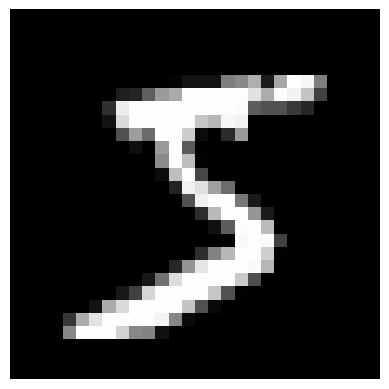

In [121]:
image = X.iloc[0].values.reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [122]:
y.head()

0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= .2, random_state=42, stratify= y)

X_train.shape, y_train.shape

((56000, 784), (56000,))

In [124]:
Labelbin = LabelBinarizer()


In [125]:
y_train_bin = Labelbin.fit_transform(y_train)
y_test_bin = Labelbin.transform(y_test)


In [126]:
y_train_bin.shape

(56000, 10)

In [127]:
print("Original label :", y_train.iloc[0])
print("Binarized label:", y_train_bin[0])


Original label : 0
Binarized label: [1 0 0 0 0 0 0 0 0 0]


### Piple Line

In [128]:
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("perceptron", Perceptron(
        random_state=42
    ))
])

In [129]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('perceptron', Perceptron(random_state=42))])

In [130]:
# Predict
y_pred = pipeline.predict(
    X_test
)


In [131]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy :",
    accuracy
)




precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    "Precision:",
    precision
)




recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    "Recall   :",
    recall
)


f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    "F1 Score :",
    f1
)






Accuracy : 0.8727857142857143
Precision: 0.8762781661272647
Recall   : 0.8716499630667254
F1 Score : 0.8706046997121477


In [132]:
y_train_pred = pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.8863392857142857


In [133]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "\nConfusion Matrix:"
)

print(cm)


Confusion Matrix:
[[1285    0    7    2   19   11   23    2   15   17]
 [   0 1471   23    1   11   19    3   11   20   16]
 [   8    5 1271    2   19   10   23   29   23    8]
 [   7    5  113 1006   15   80    9   44   44  105]
 [   2    2   12    1 1290    1   12    5    3   37]
 [  10    1   11   24   54 1033   35   19   41   35]
 [   7    1    8    0   22   16 1308    0   13    0]
 [   4    2   15    1   25    2    1 1366    0   43]
 [   3    9   33   19   68   65    9   26 1040   93]
 [   2    3    2    5  120   12    2   89    7 1149]]


## Grid

In [134]:
param_grid = {
    "perceptron__eta0": [
        0.5,
        0.25,
        0.125,
        0.0625,
        0.03125
    ]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('perceptron',
                                        Perceptron(random_state=42))]),
             n_jobs=1,
             param_grid={'perceptron__eta0': [0.5, 0.25, 0.125, 0.0625,
                                              0.03125]},
             scoring='f1_macro')

In [137]:
print("Best Parameters:")
best_params = grid_search.best_params_
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

print("\nBest CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'perceptron__eta0': 0.125}

Best CV F1:
0.8826916421197734


In [138]:
from sklearn.metrics import accuracy_score, f1_score
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

train_f1 = f1_score(y_train, train_pred, average="macro")
test_f1 = f1_score(y_test, test_pred, average="macro")

print("Training Accuracy :", train_accuracy)
print("Test Accuracy     :", test_accuracy)

print()

print("Training F1 :", train_f1)
print("Test F1     :", test_f1)

Training Accuracy : 0.8816785714285714
Test Accuracy     : 0.8703571428571428

Training F1 : 0.8787681882927343
Test F1     : 0.86704029334428


In [139]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred, average="macro"))
print("Recall   :", recall_score(y_test, best_pred, average="macro"))
print("F1 Score :", f1_score(y_test, best_pred, average="macro"))

Accuracy : 0.8703571428571428
Precision: 0.8782881513035038
Recall   : 0.8676036520065582
F1 Score : 0.86704029334428


In [140]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.97      0.94      0.95      1575
           2       0.86      0.90      0.88      1398
           3       0.93      0.70      0.80      1428
           4       0.90      0.89      0.90      1365
           5       0.93      0.64      0.76      1263
           6       0.91      0.96      0.93      1375
           7       0.85      0.94      0.90      1459
           8       0.70      0.88      0.78      1365
           9       0.78      0.86      0.82      1391

    accuracy                           0.87     14000
   macro avg       0.88      0.87      0.87     14000
weighted avg       0.88      0.87      0.87     14000



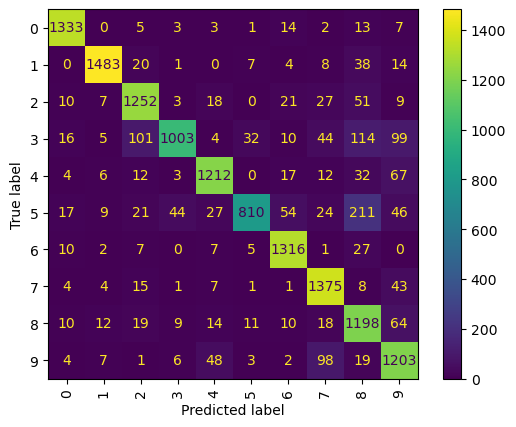

In [141]:
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.named_steps["perceptron"].classes_
)

disp.plot(xticks_rotation="vertical")
plt.show()